# Lab 4, Day 2 — Fashion-MNIST Classification

Build a classifier with proper validation tracking and early stopping, then read a
confusion matrix as an error-analysis tool rather than decoration. See
`Lab4_Day2_Instructions.md` for the full walkthrough.

This notebook is just a shell: the data loading, model, training loop, and analysis
are yours to write.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import random
random.seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)


mps


In [24]:
from torch.optim.lr_scheduler import LambdaLR
import math

def find_lr(model, train_loader, optimizer, loss_fn, 
            init_lr=1e-7, final_lr=10, num_iter=100, device="cpu"):

    model.train()
    lrs, losses = [], []
    
    # exponentially increase LR
    gamma = (final_lr / init_lr) ** (1 / num_iter)
    
    # temporary optimizer just for the test
    opt = type(optimizer)(model.parameters(), lr=init_lr)
    
    iter_count = 0
    for x, y in train_loader:
        if iter_count >= num_iter:
            break
            
        x, y = x.to(device), y.to(device)
        
        opt.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        
        # record
        lrs.append(opt.param_groups[0]["lr"])
        losses.append(loss.item())
        
        # increase LR
        for g in opt.param_groups:
            g["lr"] *= gamma
            
        iter_count += 1

    # plot
    plt.figure(figsize=(8, 5))
    plt.plot(lrs, losses)
    plt.xscale("log")
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("LR Range Test")
    plt.grid(True)
    plt.show()
    
    return lrs, losses


## Step 1: Load Fashion-MNIST and prepare loaders (`stage_b_classification.py`)

In [25]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

transform = transforms.ToTensor()
train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# TODO: load Fashion-MNIST (already cached from Day 1), split off a validation set,
# build DataLoaders - shuffle=True for training only

TRAIN_RATIO = 0.7
BATCH_SIZE = 32
# Random train/validation split
train_subset, val_subset = random_split(
    train_full,
    [
        int(TRAIN_RATIO * len(train_full)),
        len(train_full) - int(TRAIN_RATIO * len(train_full))
    ]
)


# Class names
train_subset.classes = train_full.classes 
val_subset.classes = train_full.classes

# Get all data as tensors and flatten for the MLP
X = train_full.data.float().flatten(start_dim=1) / 255.0
y = train_full.targets

X_test = test_set.data.float().flatten(start_dim=1) / 255.0
y_test = test_set.targets

# Use the indices generated by random_split
X_train = X[train_subset.indices]
y_train = y[train_subset.indices]

X_val = X[val_subset.indices]
y_val = y[val_subset.indices]



# Create TensorDatasets
train_set = TensorDataset(X_train, y_train)
val_set = TensorDataset(X_val, y_val)
test_set = TensorDataset(X_test, y_test)



# DataLoaders
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)



## Look at the data before you model it

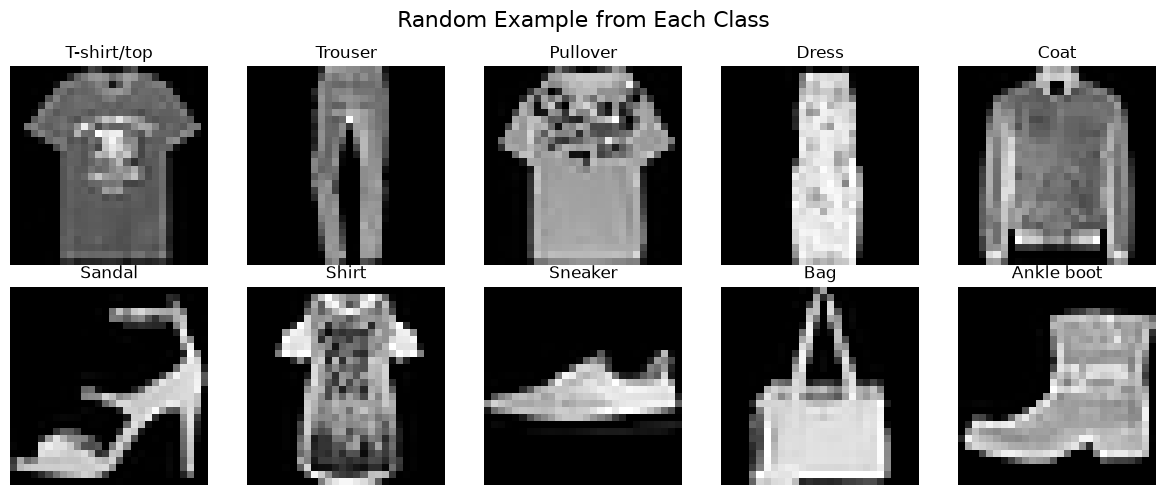

In [26]:
# TODO: plot a handful of example images, one (or a few) per class - use
# train_set.classes for the human-readable label names. This is worth doing before
# you build anything: you will be asked later whether the confusion matrix's mistakes
# are reasonable, and you cannot judge that without having actually looked at the images.


class_names = train_subset.classes
num_classes = len(class_names)

# Shuffle all training sample indices
indices = list(range(len(train_set)))
random.shuffle(indices)

examples = {}

# Find one random example for each class
for i in indices:
    image, label = train_set[i]

    if label.item() not in examples:
        examples[label.item()] = image

    if len(examples) == num_classes:
        break

# Plot
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Random Example from Each Class", fontsize=16)

for label, image in examples.items():
    axes.flat[label].imshow(image.reshape(28, 28), cmap="gray")
    axes.flat[label].set_title(class_names[label])
    axes.flat[label].axis("off")

plt.tight_layout()
plt.show()


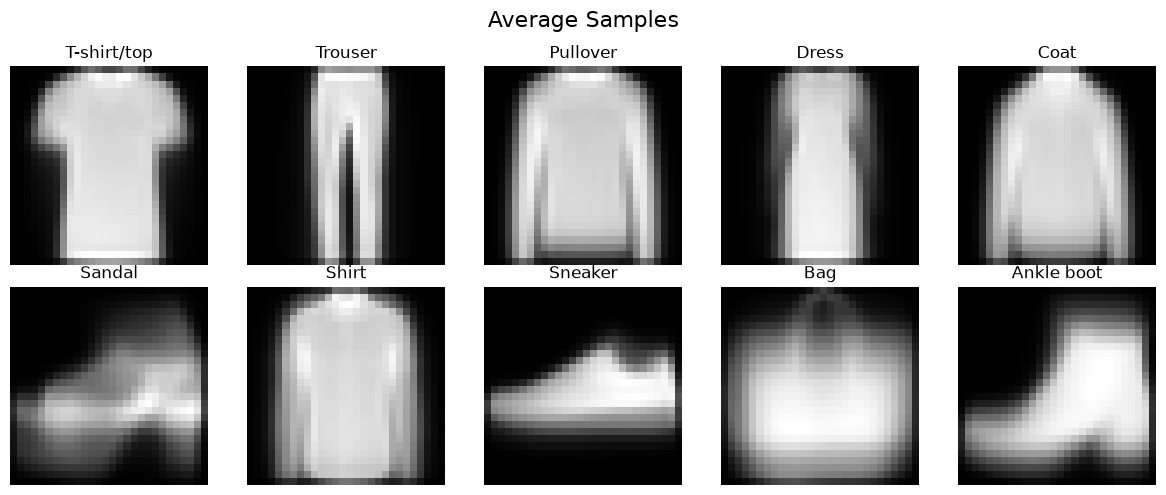

In [27]:
num_classes = len(train_subset.classes)

# Compute average image for each class
class_sum = torch.zeros(num_classes, 1, 28, 28)
class_count = torch.zeros(num_classes)

for image, label in train_subset:
    class_sum[label] += image
    class_count[label] += 1

class_avg = class_sum / class_count[:, None, None, None]

# Plot average images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Average Samples", fontsize=16)


for label, image in enumerate(class_avg):
    axes.flat[label].imshow(image.squeeze(), cmap="gray")
    axes.flat[label].set_title(train_subset.classes[label])
    axes.flat[label].axis("off")

plt.tight_layout()
plt.show()

## Step 2: The classifier

In [13]:
# TODO: Flatten -> Linear -> ReLU -> Linear (10 classes), raw scores, NO softmax -
# CrossEntropyLoss applies it internally

from train import build_mlp, training

# Flatten each 28x28 image -> 784 features
x_train = X_train.flatten(start_dim=1)
x_val = X_val.flatten(start_dim=1)
x_test = X_test.flatten(start_dim=1)

train_set = TensorDataset(x_train, y_train)
val_set = TensorDataset(x_val, y_val)
test_set = TensorDataset(x_test, y_test)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

num_features = x_train.shape[1]

EPOCH = 100
activation = 'relu'

model = build_mlp(
                    layers = [num_features, 512, 512, 256, 128, 32, 10],
                    act = activation
                ).to(device=device)


# after creating the model
for m in model.modules():
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity=activation)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# # or simply use a smaller network first
# model = build_mlp([num_features, 256, 128, 10]).to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1E-3)


# run once before real training
# lrs, losses = find_lr(model, train_loader, optimizer, loss, 
#                       init_lr=1e-7, final_lr=1, num_iter=200, device=device)

history = training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCH,
    optimizer=optimizer,
    loss_fn=loss,
    checkpoint_interval=10,
    checkpoint_path="models/",
    device=device
)


Training: 100%|██████████| 100/100 [12:38<00:00,  7.59s/it, epoch=100, train_acc=0.986, train_loss=0.0491, val_acc=0.899, val_loss=1.0148]


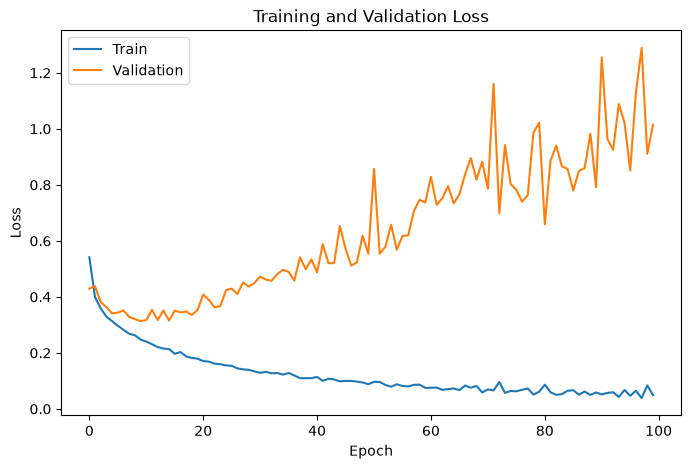

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

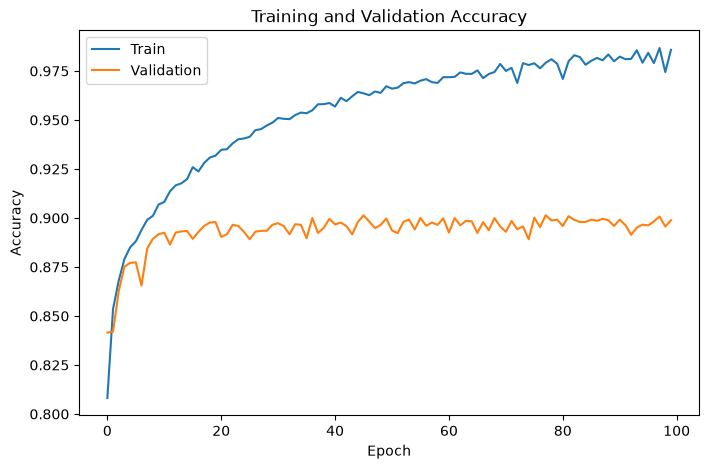

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

## Step 3: Train with validation tracking and early stopping

In [9]:
# TODO: train_with_early_stopping (or write it yourself) - track train loss and val
# accuracy per epoch, patience-based stopping (not a single bad epoch), .clone() the
# best state_dict before restoring it


In [10]:
# TODO: plot training loss and validation accuracy curves, report test accuracy


## Step 4: Confusion matrix

In [11]:
# TODO: confusion matrix on the test set - which classes get confused, and does that
# make sense given what those classes actually look like?


### Written prompt

> **Look at your training curves: validation accuracy flattens while training loss keeps
> falling. Describe what the model is doing in that gap, and explain what your early
> stopping rule actually protected you from.**

(Replace this cell's text with your answer.)

### Closing reflection

> **Across both days you used a framework to do things you had previously done by hand.
> Name one thing PyTorch genuinely did for you, and one thing it did *not* do (something
> you still had to get right yourself).**

(Replace this cell's text with your answer.)